In [3]:
import os
import urllib.request
import tarfile
def download_dataset():

    url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.tgz"

    folder = "datasets"

    os.makedirs(folder, exist_ok=True)

    file_path = os.path.join(folder, "housing.tgz")

    print("Downloading dataset...")
    urllib.request.urlretrieve(url, file_path)

    print("Extracting files...")
    tar = tarfile.open(file_path)
    tar.extractall(path=folder)
    tar.close()

    print("✅ Download Complete!")

In [4]:
download_dataset()

Extracting files...
✅ Download Complete!


In [5]:
import pandas as pd 
def load_data():
    data=pd.read_csv("datasets/housing.csv")
    return data 

In [6]:
housing=load_data()


In [7]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [9]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


AttributeError: module 'matplotlib' has no attribute 'show'

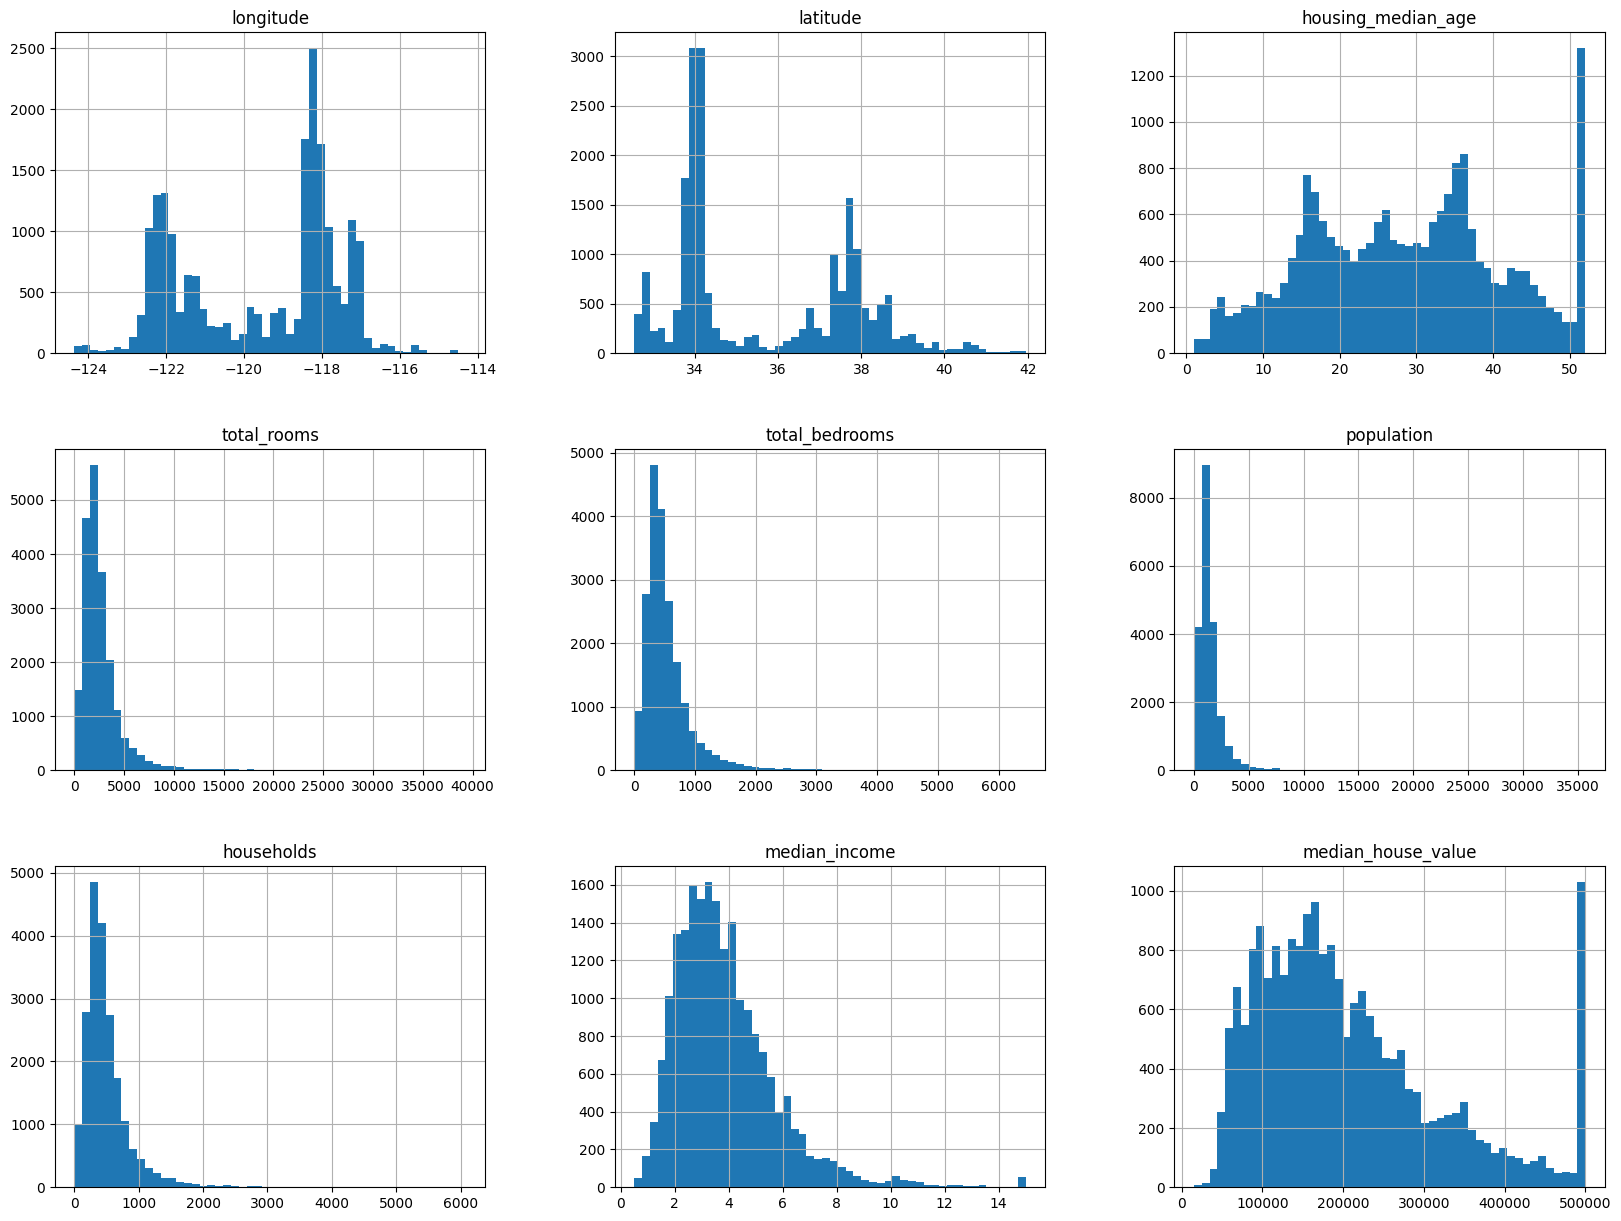

In [10]:
import matplotlib as plt 
housing.hist(bins=50,figsize=(20,15))
plt.show()

In [11]:
import numpy as np 
def split_train_test (data,test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    test_set_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]


In [12]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)

print("Training Set:", len(train_set))
print("Test Set:", len(test_set))

Training Set: 16512
Test Set: 4128


In [13]:
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)

In [14]:
housing[["median_income", "income_cat"]].head()

,median_income,income_cat
0,8.3252,6.0
1,8.3014,6.0
2,7.2574,5.0
3,5.6431,4.0
4,3.8462,3.0


In [15]:
housing.loc[housing["income_cat"] > 5, "income_cat"] = 5

In [16]:
housing["income_cat"].value_counts()

income_cat
3.0    7236
2.0    6581
4.0    3639
5.0    2362
1.0     822
Name: count, dtype: int64

AttributeError: module 'matplotlib' has no attribute 'show'

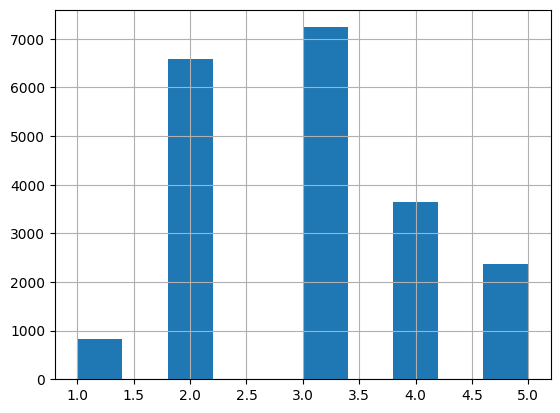

In [17]:
housing["income_cat"].hist()
plt.show()

In [18]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [19]:
print("Training Set:", len(strat_train_set))
print("Test Set:", len(strat_test_set))

Training Set: 16512
Test Set: 4128


In [20]:
print(housing["income_cat"].value_counts(normalize=True))
print(strat_train_set["income_cat"].value_counts(normalize=True))
print(strat_test_set["income_cat"].value_counts(normalize=True))

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: proportion, dtype: float64
income_cat
3.0    0.350594
2.0    0.318859
4.0    0.176296
5.0    0.114462
1.0    0.039789
Name: proportion, dtype: float64
income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: proportion, dtype: float64


In [21]:
for dataset in (strat_train_set, strat_test_set):
    dataset.drop("income_cat", axis=1, inplace=True)

<Axes: xlabel='longitude', ylabel='latitude'>

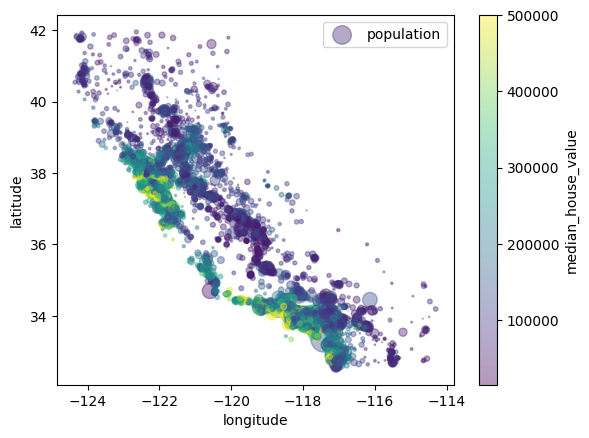

In [22]:
housing=strat_train_set.copy()
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,
s=housing["population"]/100,label="population",colorbar=True,c="median_house_value",
)


In [23]:
corr_matrix=housing.corr(numeric_only=True)
print(corr_matrix)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924478           -0.105823     0.048909   
latitude            -0.924478  1.000000            0.005737    -0.039245   
housing_median_age  -0.105823  0.005737            1.000000    -0.364535   
total_rooms          0.048909 -0.039245           -0.364535     1.000000   
total_bedrooms       0.076686 -0.072550           -0.325101     0.929391   
population           0.108071 -0.115290           -0.298737     0.855103   
households           0.063146 -0.077765           -0.306473     0.918396   
median_income       -0.019615 -0.075146           -0.111315     0.200133   
median_house_value  -0.047466 -0.142673            0.114146     0.135140   

                    total_bedrooms  population  households  median_income  \
longitude                 0.076686    0.108071    0.063146      -0.019615   
latitude                 -0.072550   -0.115290   -0.077765      -0.075146   
housing_

In [24]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

<Axes: xlabel='median_income', ylabel='median_house_value'>

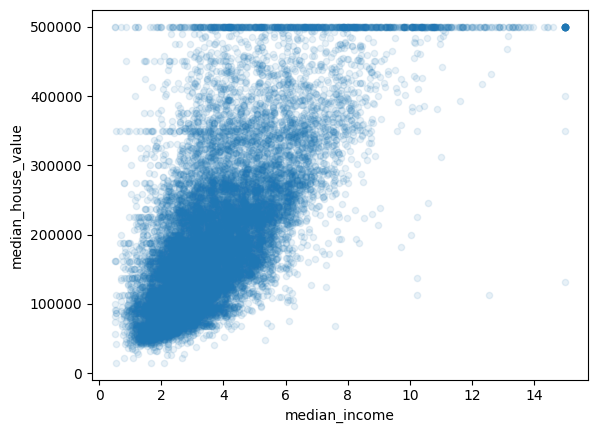

In [25]:
housing.plot(kind="scatter",x="median_income",y="median_house_value",alpha=0.1)

In [26]:
housing["rooms_per_hosehold"]=housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"]=housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [27]:
corr_matrix=housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_hosehold          0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

In [28]:
housing=strat_train_set.drop("median_house_value",axis=1)
housing_labels=strat_train_set["median_house_value"].copy()

In [29]:
from sklearn.impute import SimpleImputer 
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity",axis=1)
imputer.fit(housing_num)

housing_array=imputer.transform(housing_num)

In [30]:
housing_clean = pd.DataFrame(
    housing_array,
    columns=housing_num.columns
)
housing_clean.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

In [31]:
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder()
housing["ocean_encoded"]=encoder.fit_transform(housing["ocean_proximity"])
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,ocean_encoded
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,1
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,4
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,1
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,4
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,0


In [32]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

encoded = encoder.fit_transform(
    housing[["ocean_proximity"]]
)

print(encoded)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>
  Coords	Values
  (0, 1)	1.0
  (1, 4)	1.0
  (2, 1)	1.0
  (3, 4)	1.0
  (4, 0)	1.0
  (5, 3)	1.0
  (6, 0)	1.0
  (7, 0)	1.0
  (8, 0)	1.0
  (9, 0)	1.0
  (10, 1)	1.0
  (11, 0)	1.0
  (12, 1)	1.0
  (13, 1)	1.0
  (14, 4)	1.0
  (15, 0)	1.0
  (16, 0)	1.0
  (17, 0)	1.0
  (18, 3)	1.0
  (19, 0)	1.0
  (20, 1)	1.0
  (21, 3)	1.0
  (22, 1)	1.0
  (23, 0)	1.0
  (24, 1)	1.0
  :	:
  (16487, 1)	1.0
  (16488, 0)	1.0
  (16489, 4)	1.0
  (16490, 4)	1.0
  (16491, 1)	1.0
  (16492, 1)	1.0
  (16493, 0)	1.0
  (16494, 0)	1.0
  (16495, 0)	1.0
  (16496, 1)	1.0
  (16497, 0)	1.0
  (16498, 4)	1.0
  (16499, 0)	1.0
  (16500, 0)	1.0
  (16501, 1)	1.0
  (16502, 1)	1.0
  (16503, 1)	1.0
  (16504, 1)	1.0
  (16505, 0)	1.0
  (16506, 0)	1.0
  (16507, 0)	1.0
  (16508, 1)	1.0
  (16509, 0)	1.0
  (16510, 0)	1.0
  (16511, 1)	1.0


In [33]:
encoded.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [34]:
from sklearn.preprocessing import LabelBinarizer
encoder=LabelBinarizer(sparse_output=True)
encoded=encoder.fit_transform(housing[["ocean_proximity"]])
print(encoded)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16512 stored elements and shape (16512, 5)>
  Coords	Values
  (0, 1)	1
  (1, 4)	1
  (2, 1)	1
  (3, 4)	1
  (4, 0)	1
  (5, 3)	1
  (6, 0)	1
  (7, 0)	1
  (8, 0)	1
  (9, 0)	1
  (10, 1)	1
  (11, 0)	1
  (12, 1)	1
  (13, 1)	1
  (14, 4)	1
  (15, 0)	1
  (16, 0)	1
  (17, 0)	1
  (18, 3)	1
  (19, 0)	1
  (20, 1)	1
  (21, 3)	1
  (22, 1)	1
  (23, 0)	1
  (24, 1)	1
  :	:
  (16487, 1)	1
  (16488, 0)	1
  (16489, 4)	1
  (16490, 4)	1
  (16491, 1)	1
  (16492, 1)	1
  (16493, 0)	1
  (16494, 0)	1
  (16495, 0)	1
  (16496, 1)	1
  (16497, 0)	1
  (16498, 4)	1
  (16499, 0)	1
  (16500, 0)	1
  (16501, 1)	1
  (16502, 1)	1
  (16503, 1)	1
  (16504, 1)	1
  (16505, 0)	1
  (16506, 0)	1
  (16507, 0)	1
  (16508, 1)	1
  (16509, 0)	1
  (16510, 0)	1
  (16511, 1)	1


In [36]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,ocean_encoded
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,1
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,4
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,1
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,4
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,0


In [41]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix = 3
bedrooms_ix = 4
population_ix = 5
household_ix = 6


class CombinedAttributesAdder(BaseEstimator, TransformerMixin):

    def __init__(self, add_bedroom_per_room=True):
        self.add_bedroom_per_room = add_bedroom_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):

        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]

        population_per_household = X[:, population_ix] / X[:, household_ix]

        if self.add_bedroom_per_room:

            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]

            return np.c_[X,
                         rooms_per_household,
                         population_per_household,
                         bedrooms_per_room]

        else:

            return np.c_[X,
                         rooms_per_household,
                         population_per_household]


attr_adder = CombinedAttributesAdder(add_bedroom_per_room=False)

housing_extra_attr = attr_adder.transform(housing.values)


In [42]:
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("attr_adder",CombinedAttributesAdder()),
    ("std_scalar",StandardScaler()),
]
)
housing_num_tr=num_pipeline.fit_transform(housing_num)

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
num_attri=list(housing_num)
cat_attri=["ocean_proximity"]
full_pipeline=ColumnTransformer([
    ("num",num_pipeline,num_attri),
    ("cat",OneHotEncoder(),cat_attri)
])
housing_prepare=full_pipeline.fit_transform(housing)
housing_prepare

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 16))

In [63]:
housing = housing.drop("ocean_encoded", axis=1)

In [86]:
from sklearn.linear_model import LinearRegression
len_reg=LinearRegression()
len_reg.fit(housing_prepare,housing_labels)


some_data=housing.iloc[:5]
some_labels=housing_labels.iloc[:5]
some_data_prepared=full_pipeline.transform(some_data)
print("Predictions:\t",len_reg.predict(some_data_prepared))

Predictions:	 [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


In [87]:
print("Labels:\t",list(some_labels))

Labels:	 [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [91]:
from sklearn.metrics import mean_squared_error
Housing_predictions=len_reg.predict(housing_prepare)
reg_mse=mean_squared_error(housing_labels,Housing_predictions)
reg_rmse=np.sqrt(reg_mse)
reg_mse

4709785076.06003

In [88]:
from sklearn.tree import DecisionTreeRegressor
tree_reg=DecisionTreeRegressor()
tree_reg.fit(housing_prepare,housing_labels)

some_data=housing.iloc[:5]
some_labels=housing_labels.iloc[:5]
some_data_prepared=full_pipeline.transform(some_data)
print("Predictions:\t",tree_reg.predict(some_data_prepared))

Predictions:	 [ 72100. 279600.  82700. 112500. 238300.]


In [89]:
print("Labels:\t",list(some_labels))


Labels:	 [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [90]:
from sklearn.metrics import mean_squared_error
housing_predictions=tree_reg.predict(housing_prepare)
tree_mse=mean_squared_error(housing_labels,housing_predictions)
tree_rmse=np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(tree_reg,housing_prepare,housing_labels,scoring="neg_mean_squared_error",cv=10)
rmse_scores=np.sqrt(-scores)


In [106]:
def display_scores(scores):
    print("Score:",scores)
    print("Mean:",scores.mean())
    print("standard deviation :",scores.std())
display_scores(rmse_scores)

Score: [72192.20862643 71805.8947147  67576.13097696 72376.09264195
 68899.21109976 77763.98140719 72624.97354299 73252.04651169
 68046.78415055 71136.57993864]
Mean: 71567.39036108661
standard deviation : 2812.2085350704056


In [107]:
reg_scores=cross_val_score(len_reg,housing_prepare,housing_labels,scoring="neg_mean_squared_error",cv=10)
rmse_score=np.sqrt(-reg_scores)

In [108]:
display_scores(rmse_score)

Score: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
standard deviation : 2880.3282098180584


In [127]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)
forest_reg.fit(housing_prepare,housing_labels)
housing_predictions=forest_reg.predict(housing_prepare)
forest_mse=mean_squared_error(housing_labels,housing_predictions)
forest_rmse=np.sqrt(forest_mse)

In [128]:
scors=cross_val_score(forest_reg,housing_prepare,housing_labels,scoring="neg_mean_squared_error",cv=5)
rmse_scres=np.sqrt(-scors)

In [129]:
display_scores(rmse_scres)

Score: [50250.66345776 49669.37659509 49969.71731696 51678.29275432
 51626.69795216]
Mean: 50638.94961525762
standard deviation : 847.8904160786087


In [130]:
import joblib

In [131]:
joblib.dump(forest_reg,"forest.pkl")

['forest.pkl']

In [135]:
from sklearn.model_selection import GridSearchCV
param_grid=[
    {'n_estimators':[3,10,30],'max_features':[2,4,6,8]},
    {'bootstrap':[False],'n_estimators':[3,10],'max_features':[2,3,4]}
]
forest_reg=RandomForestRegressor()
grid_search=GridSearchCV(forest_reg,param_grid,cv=5,scoring="neg_mean_squared_error")
grid_search.fit(housing_prepare,housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for

In [136]:
grid_search.best_params_
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number 

In [143]:
cvres=grid_search.cv_results_
for mean_square,params in zip(cvres["mean_test_score"],cvres["params"]):
    print(np.sqrt(-mean_square),params)

65051.58269834521 {'max_features': 2, 'n_estimators': 3}
55777.944160934254 {'max_features': 2, 'n_estimators': 10}
52326.25495046827 {'max_features': 2, 'n_estimators': 30}
60058.77121885134 {'max_features': 4, 'n_estimators': 3}
53024.14175852779 {'max_features': 4, 'n_estimators': 10}
50458.98501505259 {'max_features': 4, 'n_estimators': 30}
58876.55003408453 {'max_features': 6, 'n_estimators': 3}
51984.52211676953 {'max_features': 6, 'n_estimators': 10}
49935.03859094407 {'max_features': 6, 'n_estimators': 30}
58873.46236608945 {'max_features': 8, 'n_estimators': 3}
51719.50329529402 {'max_features': 8, 'n_estimators': 10}
50283.576140344136 {'max_features': 8, 'n_estimators': 30}
62588.979942542035 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54049.75221271452 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60310.02261335183 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
51840.84746437304 {'bootstrap': False, 'max_features': 3, 'n_estimators':

In [141]:
print(cvres.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_features', 'param_n_estimators', 'param_bootstrap', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])
